# Freesound SVM visualization

This notebook only visualizes previously saved SVM core results.
Run the core notebook first to generate `svm_results/svm_core_results.pkl`.

In [6]:
import json
import os
import pickle
import platform
import shutil
import subprocess
from pathlib import Path

import freesound as fs
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [4]:
descriptorMapping = {
    0: 'lowlevel.spectral_centroid.mean',
    1: 'lowlevel.dissonance.mean',
    2: 'lowlevel.hfc.mean',
    3: 'sfx.logattacktime.mean',
    4: 'sfx.inharmonicity.mean',
    5: 'lowlevel.spectral_contrast.mean.0',
    6: 'lowlevel.spectral_contrast.mean.1',
    7: 'lowlevel.spectral_contrast.mean.2',
    8: 'lowlevel.spectral_contrast.mean.3',
    9: 'lowlevel.spectral_contrast.mean.4',
    10: 'lowlevel.spectral_contrast.mean.5',
    11: 'lowlevel.mfcc.mean.0',
    12: 'lowlevel.mfcc.mean.1',
    13: 'lowlevel.mfcc.mean.2',
    14: 'lowlevel.mfcc.mean.3',
    15: 'lowlevel.mfcc.mean.4',
    16: 'lowlevel.mfcc.mean.5'
}

descriptors = [
    'lowlevel.spectral_centroid.mean',
    'lowlevel.spectral_contrast.mean',
    'lowlevel.dissonance.mean',
    'lowlevel.hfc.mean',
    'lowlevel.mfcc.mean',
    'sfx.logattacktime.mean',
    'sfx.inharmonicity.mean',
]

def project_to_2d_pca(data: np.ndarray):
    if data.ndim != 2:
        raise ValueError('PCA input data must be 2D')
    centered = data - np.mean(data, axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    components = vt[:2]
    projected = centered @ components.T
    variances = (singular_values ** 2) / max(data.shape[0] - 1, 1)
    total_variance = np.sum(variances)
    explained = np.zeros(2) if total_variance == 0 else variances[:2] / total_variance
    if explained.shape[0] < 2:
        explained = np.pad(explained, (0, 2 - explained.shape[0]))
    return projected, explained

def convFtrDict2List(ftrDict):
    ftr = []
    for key in range(len(descriptorMapping.keys())):
        try:
            ftrName = '.'.join(descriptorMapping[key].split('.')[:-1])
            ind = int(descriptorMapping[key].split('.')[-1])
            ftr.append(ftrDict[ftrName][0][ind])
        except Exception:
            ftr.append(ftrDict[descriptorMapping[key]][0])
    return np.array(ftr, dtype=float)

def fetchDataDetails(inputDir, descExt='.json'):
    dataDetails = {}
    for path in Path(inputDir).rglob(f'*{descExt}'):
        sound_dir = path.parent
        class_dir = sound_dir.parent
        cname = class_dir.name
        sname = sound_dir.name
        if cname not in dataDetails:
            dataDetails[cname] = {}
        with open(path, 'r', encoding='utf-8') as file_obj:
            fDict = json.load(file_obj)
        dataDetails[cname][sname] = {'file': path.name, 'feature': fDict}
    return dataDetails

def build_svm_dataset(input_dir: str, desc_input: list[int]):
    if len(desc_input) == 0:
        raise ValueError('desc_input must contain at least one descriptor index')

    data_details = fetchDataDetails(input_dir)
    features = []
    labels = []
    sound_ids = []

    for class_name in sorted(data_details.keys()):
        for sound_name in sorted(data_details[class_name].keys()):
            full_vector = convFtrDict2List(data_details[class_name][sound_name]['feature'])
            features.append(full_vector[desc_input])
            labels.append(class_name)
            sound_ids.append(sound_name)

    return np.array(features, dtype=float), np.array(labels), sound_ids

def _standardize_train_query(train_data: np.ndarray, query_data: np.ndarray | None = None):
    mean = np.mean(train_data, axis=0, keepdims=True)
    std = np.std(train_data, axis=0, keepdims=True)
    std[std == 0] = 1.0
    scaled_train = (train_data - mean) / std
    if query_data is None:
        return scaled_train, mean, std
    scaled_query = (query_data - mean.ravel()) / std.ravel()
    return scaled_train, scaled_query, mean, std

def _infer_query_class(query_file: str) -> str | None:
    query_path = Path(query_file)
    if len(query_path.parents) >= 2:
        return query_path.parents[1].name
    return None

def download_query_sound_freesound(
    query_text: str,
    api_key: str,
    output_dir: str = 'svm_query_sound',
    top_n_results: int = 1,
    duration: tuple[int, int] = (0, 3),
    tag: str = 'pizzicato',
):
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    fs_client = fs.FreesoundClient()
    fs_client.set_token(api_key, 'token')

    flt_dur = f' duration:[{duration[0]} TO {duration[1]}]' if isinstance(duration, tuple) else ''
    flt_tag = f'tag:{tag}' if isinstance(tag, str) and tag else ''
    search_filter = f'{flt_tag}{flt_dur}'

    query_dir = output_path / query_text
    if query_dir.exists():
        shutil.rmtree(query_dir)
    query_dir.mkdir(parents=True, exist_ok=True)

    page_size = 30
    if search_filter:
        results = fs_client.text_search(
            query=query_text,
            filter=search_filter,
            sort='score',
            fields='id,name,previews,username,url,analysis',
            descriptors=','.join(descriptors),
            page_size=page_size,
            normalized=1,
        )
    else:
        results = fs_client.text_search(
            query=query_text,
            sort='score',
            fields='id,name,previews,username,url,analysis',
            descriptors=','.join(descriptors),
            page_size=page_size,
            normalized=1,
        )

    sound_count = 0
    index_count = 0
    page_no = 1
    total_sounds = min(results.count, 200)

    while sound_count < top_n_results and index_count < total_sounds:
        sound = results[index_count - ((page_no - 1) * page_size)]
        sound_dir = query_dir / str(sound.id)
        if sound_dir.exists():
            shutil.rmtree(sound_dir)
        sound_dir.mkdir(parents=True, exist_ok=True)

        preview_name = str(sound.previews.preview_lq_mp3.split('/')[-1])
        mp3_path = sound_dir / preview_name
        ftr_path = Path(str(mp3_path).replace('.mp3', '.json'))

        try:
            fs.FSRequest.retrieve(sound.previews.preview_lq_mp3, fs_client, str(mp3_path))
            features = {}
            for desc in descriptors:
                features[desc] = [eval('sound.analysis.' + desc)]
            with open(ftr_path, 'w', encoding='utf-8') as file_obj:
                json.dump(features, file_obj)
            sound_count += 1
            print(f'Downloaded query sound id={sound.id}')
        except Exception as error:
            if sound_dir.exists():
                shutil.rmtree(sound_dir)
            print(f'Failed to download sound id={sound.id}: {error}')

        index_count += 1
        if index_count % page_size == 0 and index_count < total_sounds:
            results = results.next_page()
            page_no += 1

def ensure_core_results(
    results_file: str = 'svm_results/svm_core_results.pkl',
    training_dir: str = 'svm_train_sounds',
    query_sound_name: str = 'viola',
    selected_descriptors: list[int] | None = None,
    test_size: float = 0.2,
    random_state: int = 42,
    kernel: str = 'rbf',
    C: float = 10.0,
    gamma: str | float = 'scale',
    query_top_n_results: int = 1,
    query_duration: tuple[int, int] = (0, 3),
    query_tag: str = 'pizzicato',
):
    if selected_descriptors is None:
        selected_descriptors = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

    results_path = Path(results_file)
    if results_path.exists():
        return results_path

    query_root = Path('svm_query_sound') / query_sound_name
    query_candidates = sorted(query_root.rglob('*.json'))

    if not query_candidates:
        print(f"No local query descriptor found for '{query_sound_name}'. Searching in Freesound...")
        load_dotenv()
        api_key = os.environ.get('FREESOUND_API_KEY')
        if not api_key:
            raise EnvironmentError(
                'FREESOUND_API_KEY not set. '
                'Create a .env file with FREESOUND_API_KEY=your_key (see .env.example).'
            )

        download_query_sound_freesound(
            query_text=query_sound_name,
            api_key=api_key,
            output_dir='svm_query_sound',
            top_n_results=query_top_n_results,
            duration=query_duration,
            tag=query_tag,
        )
        query_candidates = sorted(query_root.rglob('*.json'))

    if not query_candidates:
        raise FileNotFoundError(f"No query descriptor found for '{query_sound_name}' after Freesound download attempt.")

    query_file = str(query_candidates[0])
    print(f'Using query descriptor: {query_file}')

    full_features, full_labels, sound_ids = build_svm_dataset(training_dir, selected_descriptors)
    train_indices, test_indices = train_test_split(
        np.arange(len(full_features)),
        test_size=test_size,
        stratify=full_labels,
        random_state=random_state,
    )

    train_features = full_features[train_indices]
    train_labels = full_labels[train_indices]
    test_features = full_features[test_indices]
    test_labels = full_labels[test_indices]

    scaled_train_features, mean, std = _standardize_train_query(train_features)
    scaled_test_features = (test_features - mean.ravel()) / std.ravel()

    model = SVC(kernel=kernel, C=C, gamma=gamma, probability=True)
    model.fit(scaled_train_features, train_labels)

    train_pred = model.predict(scaled_train_features)
    test_pred = model.predict(scaled_test_features)
    print(f'Training set: {len(train_features)} | Test set: {len(test_features)}')
    print(f'Train accuracy: {accuracy_score(train_labels, train_pred) * 100:.1f}%')
    print(f'Test accuracy: {accuracy_score(test_labels, test_pred) * 100:.1f}%')
    print(f'Test precision: {precision_score(test_labels, test_pred, average="weighted", zero_division=0) * 100:.1f}%')
    print(f'Test recall: {recall_score(test_labels, test_pred, average="weighted", zero_division=0) * 100:.1f}%')
    print(f'Test F1: {f1_score(test_labels, test_pred, average="weighted", zero_division=0) * 100:.1f}%')
    print('Confusion matrix (test):')
    print(confusion_matrix(test_labels, test_pred, labels=sorted(np.unique(test_labels))))

    with open(query_file, 'r', encoding='utf-8') as file_obj:
        query_dict = json.load(file_obj)
    query_features = convFtrDict2List(query_dict)[selected_descriptors].astype(float)
    scaled_query_features = (query_features - mean.ravel()) / std.ravel()

    predicted_label = model.predict([scaled_query_features])[0]
    probabilities = model.predict_proba([scaled_query_features])[0]
    predicted_probability = float(dict(zip(model.classes_, probabilities))[predicted_label])
    query_label = _infer_query_class(query_file)

    bundle = {
        'combined_scaled_features': np.vstack((scaled_train_features, scaled_test_features)),
        'combined_labels': np.concatenate((train_labels, test_labels)),
        'combined_sound_ids': [sound_ids[i] for i in train_indices] + [sound_ids[i] for i in test_indices],
        'test_mask': np.concatenate((np.zeros(len(train_features), dtype=bool), np.ones(len(test_features), dtype=bool))),
        'support_indices': model.support_,
        'scaled_query_features': scaled_query_features,
        'query_label': query_label,
        'predicted_label': predicted_label,
        'predicted_probability': predicted_probability,
        'kernel': kernel,
        'C': C,
        'gamma': gamma,
    }

    results_path.parent.mkdir(parents=True, exist_ok=True)
    with open(results_path, 'wb') as file_obj:
        pickle.dump(bundle, file_obj)

    print(f'Predicted query class: {predicted_label} ({predicted_probability * 100:.1f}%)')
    print(f'Saved core results to: {results_path}')
    return results_path

Matplotlib backend: widget


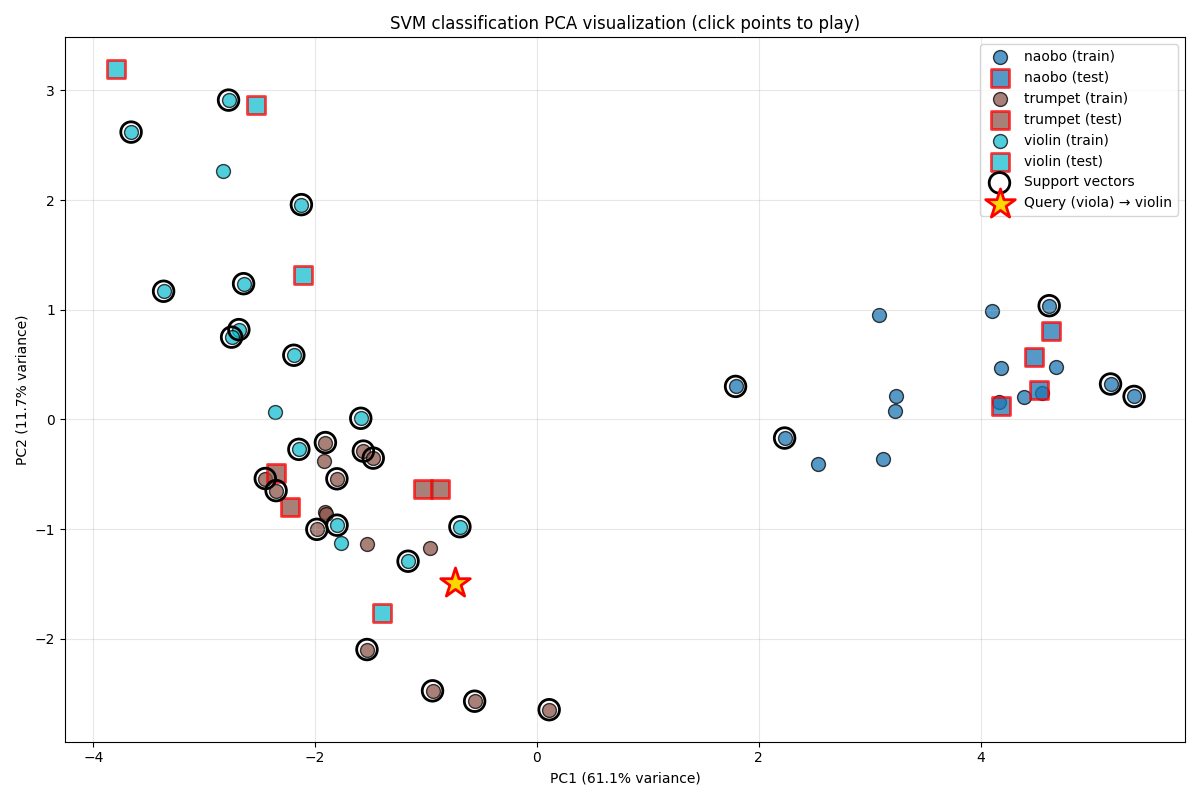

Query prediction: violin (93.0%)
Tip: click points in the plot to play their audio preview.


Fallback controls ready: use the dropdown + button if direct plot clicks are unavailable.


In [9]:
results_file = ensure_core_results(
    results_file='svm_results/svm_core_results.pkl',
    training_dir='svm_train_sounds',
    query_sound_name='viola',
    selected_descriptors=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    test_size=0.2,
    random_state=42,
    kernel='rbf',
    C=10.0,
    gamma='scale',
    query_top_n_results=1,
    query_duration=(0, 3),
    query_tag='pizzicato',
)

with open(results_file, 'rb') as file_obj:
    bundle = pickle.load(file_obj)

combined_scaled_features = bundle['combined_scaled_features']
combined_labels = np.array(bundle['combined_labels'])
combined_sound_ids = list(bundle['combined_sound_ids'])
test_mask = np.array(bundle['test_mask'], dtype=bool)
support_indices = np.array(bundle['support_indices'])
query_point = np.array(bundle['scaled_query_features']).reshape(1, -1)
query_label = bundle['query_label']
predicted_label = bundle['predicted_label']
predicted_probability = bundle['predicted_probability']

# Configure interactive backend for click callbacks
ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        try:
            ip.run_line_magic('matplotlib', 'notebook')
        except Exception:
            pass

current_backend = matplotlib.get_backend().lower()
print(f'Matplotlib backend: {current_backend}')
if 'inline' in current_backend:
    print('Interactive clicks are disabled with inline backend. Use `%matplotlib widget` and rerun this cell.')

def _collect_audio_file_map(base_dir: str | Path) -> dict[tuple[str, str], Path]:
    base_path = Path(base_dir)
    audio_map = {}
    if not base_path.exists():
        return audio_map
    for class_dir in sorted(path for path in base_path.iterdir() if path.is_dir()):
        for sound_dir in sorted(path for path in class_dir.iterdir() if path.is_dir()):
            audio_file = None
            for pattern in ('*.mp3', '*.ogg', '*.wav'):
                matches = sorted(sound_dir.glob(pattern))
                if matches:
                    audio_file = matches[0]
                    break
            if audio_file is not None:
                audio_map[(class_dir.name, sound_dir.name)] = audio_file
    return audio_map

def _find_query_audio_file(query_class_name: str | None) -> Path | None:
    if not query_class_name:
        return None
    query_dir = Path('svm_query_sound') / query_class_name
    if not query_dir.exists():
        return None
    for pattern in ('*.mp3', '*.ogg', '*.wav'):
        matches = sorted(query_dir.rglob(pattern))
        if matches:
            return matches[0]
    return None

audio_map = _collect_audio_file_map('svm_train_sounds')
query_audio_file = _find_query_audio_file(query_label)

all_points = np.vstack((combined_scaled_features, query_point))
projected, explained = project_to_2d_pca(all_points)
projected_train = projected[:-1]
projected_query = projected[-1]

fig, ax = plt.subplots(figsize=(12, 8))
unique_labels = sorted(np.unique(combined_labels))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))
color_map = {label: colors[idx % len(colors)] for idx, label in enumerate(unique_labels)}

point_to_indices: dict[object, np.ndarray] = {}

for class_name in unique_labels:
    idx = np.where(combined_labels == class_name)[0]
    train_idx = idx[~test_mask[idx]]
    test_idx = idx[test_mask[idx]]

    if len(train_idx) > 0:
        scatter_train = ax.scatter(
            projected_train[train_idx, 0],
            projected_train[train_idx, 1],
            c=[color_map[class_name]],
            s=100,
            alpha=0.75,
            edgecolors='black',
            linewidth=1,
            picker=True,
            pickradius=8,
            label=class_name if len(test_idx) == 0 else f'{class_name} (train)',
        )
        point_to_indices[scatter_train] = train_idx

    if len(test_idx) > 0:
        scatter_test = ax.scatter(
            projected_train[test_idx, 0],
            projected_train[test_idx, 1],
            c=[color_map[class_name]],
            s=150,
            alpha=0.75,
            edgecolors='red',
            linewidth=2,
            marker='s',
            picker=True,
            pickradius=8,
            label=f'{class_name} (test)',
        )
        point_to_indices[scatter_test] = test_idx

if len(support_indices) > 0:
    ax.scatter(
        projected_train[support_indices, 0],
        projected_train[support_indices, 1],
        s=220,
        facecolors='none',
        edgecolors='black',
        linewidth=2,
        label='Support vectors',
        zorder=4,
    )

query_artist = ax.scatter(
    projected_query[0],
    projected_query[1],
    c='gold',
    marker='*',
    s=500,
    edgecolors='red',
    linewidth=2,
    picker=True,
    pickradius=10,
    label=f'Query ({query_label}) → {predicted_label}',
    zorder=5,
)
point_to_indices[query_artist] = np.array([-1])

ax.set_xlabel(f'PC1 ({explained[0] * 100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1] * 100:.1f}% variance)')
ax.set_title('SVM classification PCA visualization (click points to play)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

annot = ax.annotate(
    '',
    xy=(0, 0),
    xytext=(20, 20),
    textcoords='offset points',
    bbox=dict(boxstyle='round', fc='yellow', alpha=0.9),
    arrowprops=dict(arrowstyle='->'),
)
annot.set_visible(False)

playback_process = None

def play_file(audio_file: Path | None):
    global playback_process
    if audio_file is None:
        print('No audio file available to play for this point.')
        return
    try:
        if playback_process is not None and playback_process.poll() is None:
            playback_process.terminate()
        if platform.system() == 'Darwin':
            playback_process = subprocess.Popen(['afplay', str(audio_file)])
        elif platform.system() == 'Linux':
            playback_process = subprocess.Popen(['aplay', str(audio_file)])
        elif platform.system() == 'Windows':
            playback_process = subprocess.Popen(['start', str(audio_file)], shell=True)
        else:
            print(f'Unsupported OS for playback. File: {audio_file}')
            return
        print(f'Playing: {audio_file.name}')
    except Exception as error:
        print(f'Error playing sound: {error}')

def _audio_for_index(index: int) -> Path | None:
    if index == -1:
        return query_audio_file
    class_name = str(combined_labels[index])
    sound_id = combined_sound_ids[index]
    return audio_map.get((class_name, sound_id))

def show_training_info(index: int):
    class_name = str(combined_labels[index])
    sound_id = combined_sound_ids[index]
    audio_file = _audio_for_index(index)
    play_file(audio_file)

    annot.xy = (projected_train[index, 0], projected_train[index, 1])
    annot.set_text(
        '\n'.join([
            f'Sound ID: {sound_id}',
            f'Class: {class_name}',
            f'Set: {"test" if test_mask[index] else "train"}',
            f'Support vector: {"yes" if index in support_indices else "no"}',
        ])
    )
    annot.set_visible(True)
    fig.canvas.draw_idle()

def show_query_info():
    play_file(_audio_for_index(-1))
    annot.xy = (projected_query[0], projected_query[1])
    annot.set_text(
        '\n'.join([
            'Sound: query',
            f'True class: {query_label}',
            f'Predicted class: {predicted_label}',
            f'Confidence: {predicted_probability * 100:.1f}%',
        ])
    )
    annot.set_visible(True)
    fig.canvas.draw_idle()

def show_info(meta_index: int):
    if meta_index == -1:
        show_query_info()
    else:
        show_training_info(meta_index)

def on_pick(event):
    artist = event.artist
    if artist not in point_to_indices or len(event.ind) == 0:
        return
    show_info(int(point_to_indices[artist][event.ind[0]]))

fallback_points = np.vstack((projected_train, projected_query.reshape(1, -1)))
fallback_meta = np.append(np.arange(len(combined_labels)), -1)

def on_click(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return
    distances = np.sqrt((fallback_points[:, 0] - event.xdata) ** 2 + (fallback_points[:, 1] - event.ydata) ** 2)
    show_info(int(fallback_meta[int(np.argmin(distances))]))

fig.canvas.mpl_connect('pick_event', on_pick)
fig.canvas.mpl_connect('button_press_event', on_click)

plt.tight_layout()
plt.show()

print(f'Query prediction: {predicted_label} ({predicted_probability * 100:.1f}%)')
print('Tip: click points in the plot to play their audio preview.')

# Fallback controls for non-interactive/static renderers
try:
    import ipywidgets as widgets
    from IPython.display import display

    selector_options = []
    for idx in range(len(combined_labels)):
        set_name = 'test' if test_mask[idx] else 'train'
        label = f'{idx:03d} | {combined_labels[idx]} | {combined_sound_ids[idx]} | {set_name}'
        selector_options.append((label, int(idx)))
    selector_options.append((f'query | {query_label} → {predicted_label}', -1))

    point_selector = widgets.Dropdown(
        options=selector_options,
        value=0 if len(selector_options) > 1 else -1,
        description='Point:',
        layout=widgets.Layout(width='90%'),
    )
    play_button = widgets.Button(description='Play selected', button_style='primary')
    playback_output = widgets.Output()

    def _on_play_button_clicked(_):
        with playback_output:
            playback_output.clear_output(wait=True)
            show_info(int(point_selector.value))

    play_button.on_click(_on_play_button_clicked)

    display(widgets.VBox([
        widgets.HTML('<b>Fallback playback controls</b>'),
        point_selector,
        play_button,
        playback_output,
    ]))
    print('Fallback controls ready: use the dropdown + button if direct plot clicks are unavailable.')
except Exception as error:
    print(f'Fallback controls unavailable ({error}). You can still use plot clicks when interactive backend is enabled.')